# HW12 – временные ряды: temporal split, baseline-модели и GRU-прогноз

In [1]:
from __future__ import annotations

import copy
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

plt.style.use("seaborn-v0_8-whitegrid")

TARGET_COLUMN = "target"
DATE_COLUMN = "date"
DATASET_NAME = "S12-hw-dataset.csv"
BASELINE_FEATURE_COLUMNS = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_24",
    "lag_168",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_24",
    "rolling_std_24",
    "day_of_week",
    "hour",
    "is_weekend",
]

if Path(DATASET_NAME).exists():
    BASE_DIR = Path(".").resolve()
else:
    BASE_DIR = Path("homeworks/HW12").resolve()

ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = BASE_DIR / DATASET_NAME

SEED = 42


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


@dataclass(frozen=True)
class TemporalSplit:
    train_end: int
    val_end: int
    train: pd.DataFrame
    val: pd.DataFrame
    test: pd.DataFrame

    @property
    def val_start_timestamp(self) -> pd.Timestamp:
        return self.val.iloc[0][DATE_COLUMN]

    @property
    def test_start_timestamp(self) -> pd.Timestamp:
        return self.test.iloc[0][DATE_COLUMN]

    @property
    def summary(self) -> str:
        train_range = f"{self.train.iloc[0][DATE_COLUMN]}..{self.train.iloc[-1][DATE_COLUMN]}"
        val_range = f"{self.val.iloc[0][DATE_COLUMN]}..{self.val.iloc[-1][DATE_COLUMN]}"
        test_range = f"{self.test.iloc[0][DATE_COLUMN]}..{self.test.iloc[-1][DATE_COLUMN]}"
        return (
            f"train={len(self.train)}[{train_range}]; "
            f"val={len(self.val)}[{val_range}]; "
            f"test={len(self.test)}[{test_range}]"
        )


def regression_metrics(y_true: Sequence[float], y_pred: Sequence[float]) -> dict[str, float]:
    true = np.asarray(y_true, dtype=float)
    pred = np.asarray(y_pred, dtype=float)
    epsilon = 1e-8
    mae = mean_absolute_error(true, pred)
    rmse = math.sqrt(mean_squared_error(true, pred))
    mape = float(np.mean(np.abs((true - pred) / np.clip(np.abs(true), epsilon, None))) * 100)
    return {"mae": float(mae), "rmse": float(rmse), "mape": mape}


def temporal_split(
    frame: pd.DataFrame,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
) -> TemporalSplit:
    if not 0 < train_ratio < 1:
        raise ValueError("train_ratio must be between 0 and 1")
    if not 0 < val_ratio < 1:
        raise ValueError("val_ratio must be between 0 and 1")
    if train_ratio + val_ratio >= 1:
        raise ValueError("train_ratio + val_ratio must be less than 1")

    n_rows = len(frame)
    train_end = int(n_rows * train_ratio)
    val_end = int(n_rows * (train_ratio + val_ratio))

    train = frame.iloc[:train_end].copy()
    val = frame.iloc[train_end:val_end].copy()
    test = frame.iloc[val_end:].copy()

    return TemporalSplit(
        train_end=train_end,
        val_end=val_end,
        train=train,
        val=val,
        test=test,
    )


def naive_last_predictions(frame: pd.DataFrame) -> pd.Series:
    return frame[TARGET_COLUMN].shift(1)


def moving_average_predictions(frame: pd.DataFrame, window: int) -> pd.Series:
    return frame[TARGET_COLUMN].shift(1).rolling(window).mean()


def fit_ridge_baseline(train_frame: pd.DataFrame) -> Pipeline:
    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=1.0)),
        ]
    )
    model.fit(train_frame[BASELINE_FEATURE_COLUMNS], train_frame[TARGET_COLUMN])
    return model


def evaluate_ridge(model: Pipeline, frame: pd.DataFrame) -> tuple[np.ndarray, dict[str, float]]:
    predictions = model.predict(frame[BASELINE_FEATURE_COLUMNS])
    metrics = regression_metrics(frame[TARGET_COLUMN], predictions)
    return predictions, metrics


class GRUForecastModel(nn.Module):
    def __init__(
        self,
        input_size: int = 1,
        hidden_size: int = 32,
        num_layers: int = 1,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, _ = self.gru(x)
        last_hidden = output[:, -1, :]
        return self.head(last_hidden).squeeze(-1)


def inverse_scale_array(values: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values.reshape(-1, 1)).reshape(-1)


def predict_gru(
    model: nn.Module,
    loader: DataLoader,
    scaler: StandardScaler,
    device: torch.device,
) -> np.ndarray:
    model.eval()
    predictions: list[np.ndarray] = []
    with torch.no_grad():
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x).detach().cpu().numpy()
            predictions.append(outputs)
    if not predictions:
        return np.array([], dtype=float)
    scaled_predictions = np.concatenate(predictions)
    return inverse_scale_array(scaled_predictions, scaler)


def evaluate_gru(
    model: nn.Module,
    loader: DataLoader,
    frame: pd.DataFrame,
    scaler: StandardScaler,
    target_indices: Sequence[int],
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, dict[str, float]]:
    predictions = predict_gru(model, loader, scaler, device)
    targets = frame.iloc[list(target_indices)][TARGET_COLUMN].to_numpy()
    metrics = regression_metrics(targets, predictions)
    return targets, predictions, metrics


def train_gru_model(
    loaders: dict[str, DataLoader],
    frame: pd.DataFrame,
    scaler: StandardScaler,
    split_indices: dict[str, list[int]],
    device: torch.device,
    *,
    hidden_size: int,
    num_layers: int,
    dropout: float,
    learning_rate: float,
    max_epochs: int,
    patience: int,
) -> tuple[nn.Module, list[dict[str, float]], dict[str, float], int]:
    model = GRUForecastModel(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    history: list[dict[str, float]] = []
    best_state: dict[str, torch.Tensor] | None = None
    best_metrics: dict[str, float] | None = None
    best_epoch = 0
    best_val_mae = math.inf
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        batch_losses: list[float] = []
        for batch_x, batch_y in loaders["train"]:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            batch_losses.append(float(loss.item()))

        _, _, val_metrics = evaluate_gru(
            model=model,
            loader=loaders["val"],
            frame=frame,
            scaler=scaler,
            target_indices=split_indices["val"],
            device=device,
        )
        train_loss = float(np.mean(batch_losses)) if batch_losses else math.nan
        history.append(
            {
                "epoch": float(epoch),
                "train_loss": train_loss,
                "val_mae": val_metrics["mae"],
                "val_rmse": val_metrics["rmse"],
                "val_mape": val_metrics["mape"],
            }
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_metrics = copy.deepcopy(val_metrics)
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state is None or best_metrics is None:
        raise RuntimeError("GRU training did not produce a valid checkpoint")

    model.load_state_dict(best_state)
    return model, history, best_metrics, best_epoch


def save_json(path: str | Path, payload: dict[str, object]) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(payload, file, ensure_ascii=False, indent=2, default=str)


def rows_to_frame(rows: Iterable[dict[str, object]]) -> pd.DataFrame:
    return pd.DataFrame(list(rows))


set_seed(SEED)
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"BASE_DIR: {BASE_DIR}")
print({"sklearn_version": sklearn.__version__, "cuda_available": CUDA_AVAILABLE, "device": str(DEVICE)})

BASE_DIR: /Users/hilez/institute-of-ai/homeworks/HW12
{'sklearn_version': '1.8.0', 'cuda_available': False, 'device': 'cpu'}


## План эксперимента

Фиксированный temporal split: 70% train, 15% validation, 15% test.
Сравниваются B1, B2, B3, R1.
Модель выбирается по MAE на validation (дополнительно — RMSE, MAPE).
Test используется один раз — для финальной оценки лучшей модели.

In [2]:
config = {
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "moving_average_window": 2,
    "window_size": 168,
    "horizon": 1,
    "gru_hidden_size": 32,
    "gru_num_layers": 1,
    "gru_dropout": 0.0,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "max_epochs": 25,
    "patience": 5,
}
config

{'train_ratio': 0.7,
 'val_ratio': 0.15,
 'moving_average_window': 2,
 'window_size': 168,
 'horizon': 1,
 'gru_hidden_size': 32,
 'gru_num_layers': 1,
 'gru_dropout': 0.0,
 'batch_size': 64,
 'learning_rate': 0.001,
 'max_epochs': 25,
 'patience': 5}

## 1. Данные и первичный анализ

In [3]:
frame = pd.read_csv(DATA_PATH)
frame["date"] = pd.to_datetime(frame["date"])
frame = frame.sort_values("date").reset_index(drop=True)

# sanity-check: missing values after CSV loading and explicit date handling
missing_by_column = frame.isna().sum().sort_values(ascending=False)
summary = {
    "n_rows": int(len(frame)),
    "date_min": frame["date"].min(),
    "date_max": frame["date"].max(),
    "date_column": "date",
    "missing_by_column": missing_by_column.to_dict(),
    "frequency": pd.infer_freq(frame["date"]),
}

print(f"Наблюдений: {summary['n_rows']}")
print(f"Диапазон дат: {summary['date_min']} .. {summary['date_max']}")
print(f"Частота ряда: {summary['frequency']}")

pd.Series(summary["missing_by_column"], name="missing_values")

Наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 .. 2025-06-29 23:00:00
Частота ряда: h


date      0
target    0
Name: missing_values, dtype: int64

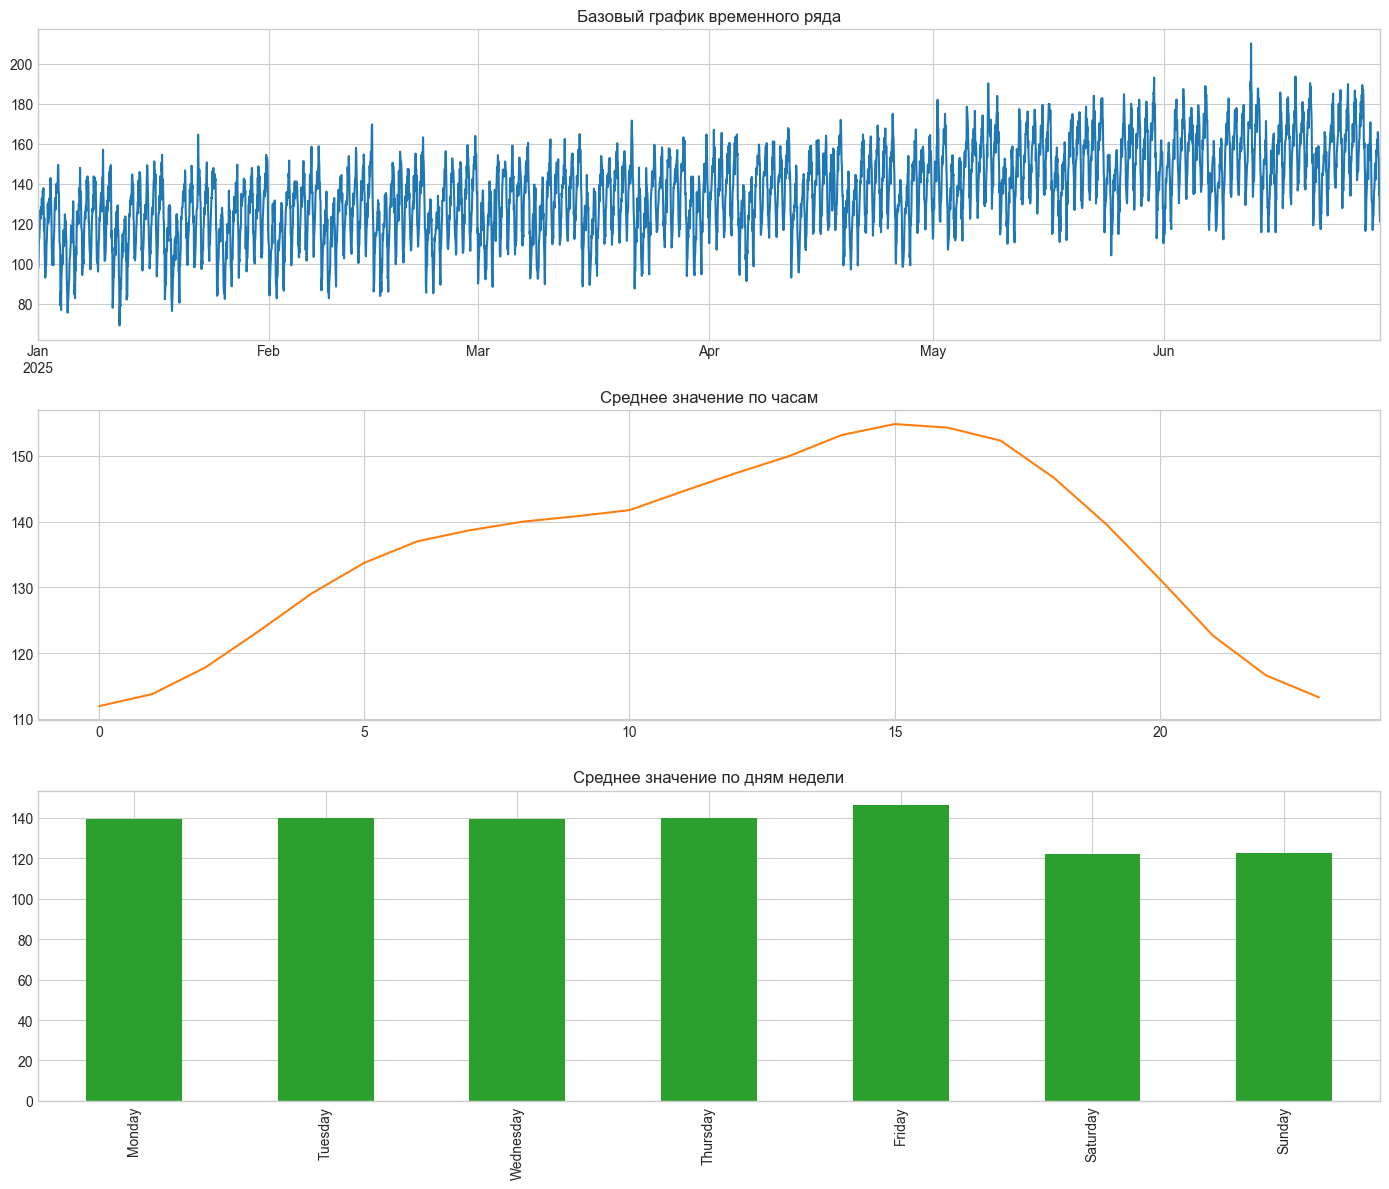

In [4]:
hourly_profile = frame.groupby(frame[DATE_COLUMN].dt.hour)[TARGET_COLUMN].mean()
weekday_profile = frame.groupby(frame[DATE_COLUMN].dt.day_name())[TARGET_COLUMN].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
frame.plot(x=DATE_COLUMN, y=TARGET_COLUMN, ax=axes[0], color="tab:blue", legend=False, title="Базовый график временного ряда")
hourly_profile.plot(ax=axes[1], color="tab:orange", title="Среднее значение по часам")
weekday_profile.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).plot(
    kind="bar", ax=axes[2], color="tab:green", title="Среднее значение по дням недели"
)
for axis in axes:
    axis.set_xlabel("")
plt.tight_layout()
plt.show()

По ряду заметен восходящий тренд: средний уровень в конце периода выше, чем в начале.

Также выражена внутрисуточная сезонность: днём значения выше, ночью ниже. По профилю дня недели видно проседание на выходных, поэтому для baseline-модели полезны как лаги и rolling-статистики, так и календарные признаки.

## 2. Корректный temporal split

{'train_ratio': 0.7, 'validation_ratio': 0.15, 'test_ratio': 0.15000000000000005}
train=3024[2025-01-01 00:00:00..2025-05-06 23:00:00]; val=648[2025-05-07 00:00:00..2025-06-02 23:00:00]; test=648[2025-06-03 00:00:00..2025-06-29 23:00:00]


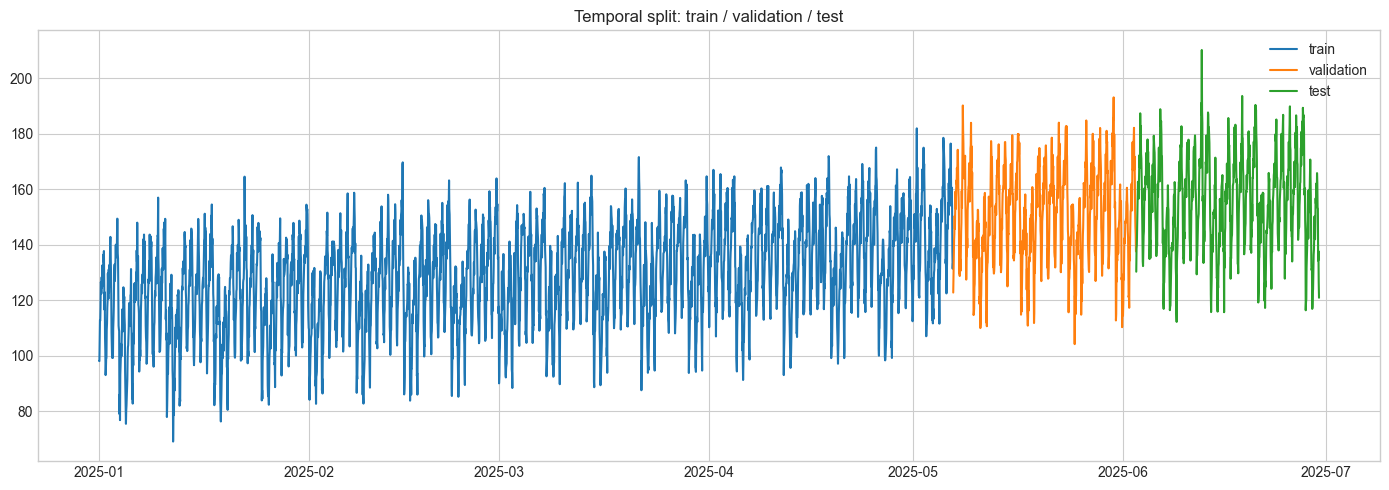

Сохранено: /Users/hilez/institute-of-ai/homeworks/HW12/artifacts/figures/series_split.png


,split,rows,start,end
0,train,3024,2025-01-01,2025-05-06 23:00:00
1,validation,648,2025-05-07,2025-06-02 23:00:00
2,test,648,2025-06-03,2025-06-29 23:00:00


In [5]:
train_ratio = config["train_ratio"]
val_ratio = config["val_ratio"]
test_ratio = 1.0 - train_ratio - val_ratio
split = temporal_split(frame, train_ratio=train_ratio, val_ratio=val_ratio)
train = split.train.copy()
validation = split.val.copy()
test = split.test.copy()

assert len(train) + len(validation) + len(test) == len(frame)
assert train[DATE_COLUMN].max() < validation[DATE_COLUMN].min() < test[DATE_COLUMN].min()

split_overview = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train),
            "start": train[DATE_COLUMN].min(),
            "end": train[DATE_COLUMN].max(),
        },
        {
            "split": "validation",
            "rows": len(validation),
            "start": validation[DATE_COLUMN].min(),
            "end": validation[DATE_COLUMN].max(),
        },
        {
            "split": "test",
            "rows": len(test),
            "start": test[DATE_COLUMN].min(),
            "end": test[DATE_COLUMN].max(),
        },
    ]
)

print({"train_ratio": train_ratio, "validation_ratio": val_ratio, "test_ratio": test_ratio})
print(split.summary)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[DATE_COLUMN], train[TARGET_COLUMN], label="train", color="tab:blue")
ax.plot(validation[DATE_COLUMN], validation[TARGET_COLUMN], label="validation", color="tab:orange")
ax.plot(test[DATE_COLUMN], test[TARGET_COLUMN], label="test", color="tab:green")
ax.set_title("Temporal split: train / validation / test")
ax.legend()
plt.tight_layout()
split_figure_path = FIGURES_DIR / "series_split.png"
fig.savefig(split_figure_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Сохранено: {split_figure_path}")

split_overview

Случайный `random split` здесь некорректен, потому что модель в таком режиме получает информацию из будущего периода в train-части и затем проверяется на точках из прошлого или смешанного контекста. Для временного ряда это даёт нереалистичную оценку качества и скрытую утечку данных.

## 3. Лаговые, rolling- и календарные признаки для baseline-моделей

In [6]:
baseline_features_frame = frame.copy()
baseline_features_frame["lag_1"] = baseline_features_frame[TARGET_COLUMN].shift(1)
baseline_features_frame["lag_7"] = baseline_features_frame[TARGET_COLUMN].shift(7)
baseline_features_frame["lag_14"] = baseline_features_frame[TARGET_COLUMN].shift(14)
baseline_features_frame["lag_24"] = baseline_features_frame[TARGET_COLUMN].shift(24)
baseline_features_frame["lag_168"] = baseline_features_frame[TARGET_COLUMN].shift(168)
shifted_target = baseline_features_frame[TARGET_COLUMN].shift(1)
baseline_features_frame["rolling_mean_7"] = shifted_target.rolling(7).mean()
baseline_features_frame["rolling_std_7"] = shifted_target.rolling(7).std()
baseline_features_frame["rolling_mean_24"] = shifted_target.rolling(24).mean()
baseline_features_frame["rolling_std_24"] = shifted_target.rolling(24).std()
baseline_features_frame["day_of_week"] = baseline_features_frame["date"].dt.dayofweek
baseline_features_frame["hour"] = baseline_features_frame["date"].dt.hour
baseline_features_frame["is_weekend"] = (baseline_features_frame["day_of_week"] >= 5).astype(int)
baseline_features_frame = baseline_features_frame.dropna().reset_index(drop=True)

baseline_train = baseline_features_frame[baseline_features_frame["date"] < validation["date"].iloc[0]].copy()
baseline_val = baseline_features_frame[(baseline_features_frame["date"] >= validation["date"].iloc[0]) & (baseline_features_frame["date"] < test["date"].iloc[0])].copy()
baseline_test = baseline_features_frame[baseline_features_frame["date"] >= test["date"].iloc[0]].copy()
feature_preview = baseline_train[["date", TARGET_COLUMN] + BASELINE_FEATURE_COLUMNS].head()
print(f"Train rows for B3 after feature engineering: {len(baseline_train)}")
print(f"Validation rows for B3: {len(baseline_val)}")
print(f"Test rows for B3: {len(baseline_test)}")
feature_preview

Train rows for B3 after feature engineering: 2856
Validation rows for B3: 648
Test rows for B3: 648


,date,target,lag_1,lag_7,lag_14,lag_24,lag_168,rolling_mean_7,rolling_std_7,rolling_mean_24,rolling_std_24,day_of_week,hour,is_weekend
0,2025-01-08 00:00:00,97.11,104.82,141.22,129.36,98.53,98.14,120.507143,14.492322,122.167500,14.110294,2,0,0
1,2025-01-08 01:00:00,97.44,97.11,137.81,126.26,102.16,98.07,114.205714,13.543831,122.108333,14.216298,2,1,0
2,2025-01-08 02:00:00,101.13,97.44,120.70,141.90,99.82,104.70,108.438571,9.930756,121.911667,14.533371,2,2,0
3,2025-01-08 03:00:00,106.67,101.13,121.47,138.13,104.86,112.81,105.642857,8.564266,121.966250,14.449009,2,3,0
4,2025-01-08 04:00:00,114.46,106.67,110.88,132.69,116.19,112.62,103.528571,5.153398,122.041667,14.360292,2,4,0


## 4. Baseline-эксперименты B1, B2, B3

In [7]:
b1_val_predictions = naive_last_predictions(frame).loc[split.val.index].to_numpy()
b1_val_metrics = regression_metrics(split.val[TARGET_COLUMN], b1_val_predictions)

b2_val_predictions = moving_average_predictions(frame, config["moving_average_window"]).loc[split.val.index].to_numpy()
b2_val_metrics = regression_metrics(split.val[TARGET_COLUMN], b2_val_predictions)

# scaler / normalization for B3 is fit only on train inside fit_ridge_baseline
baseline_scaler = StandardScaler()
b3_reference_model = Ridge(alpha=1.0)
linear_regression_reference = LinearRegression()
ridge_model = fit_ridge_baseline(baseline_train)
b3_val_predictions, b3_val_metrics = evaluate_ridge(ridge_model, baseline_val)

baseline_results = pd.DataFrame([
    {"experiment_id": "B1", "model": "naive-last", **b1_val_metrics},
    {"experiment_id": "B2", "model": f"moving-average(window={config['moving_average_window']})", **b2_val_metrics},
    {"experiment_id": "B3", "model": "ridge-lag-features", **b3_val_metrics},
]).set_index("experiment_id")
baseline_results

,model,mae,rmse,mape
experiment_id,,,,
B1,naive-last,6.444815,8.201023,4.397922
B2,moving-average(window=2),7.087461,8.827727,4.852069
B3,ridge-lag-features,4.807380,6.163091,3.214340


В этом наборе данных даже наивный baseline оказывается не совсем слабым

## 5. GRU-прогнозирование (R1)

Для рекуррентной модели ниже **явно** строятся:

- оконное представление ряда через `WindowForecastDataset`;
- отдельные `train`, `validation` и `test` датасеты;
- отдельные `DataLoader` для каждой части temporal split.


{'train_window_batch_shape': (64, 168, 1), 'train_target_batch_shape': (64,), 'window_size': 168, 'batch_size': 64}


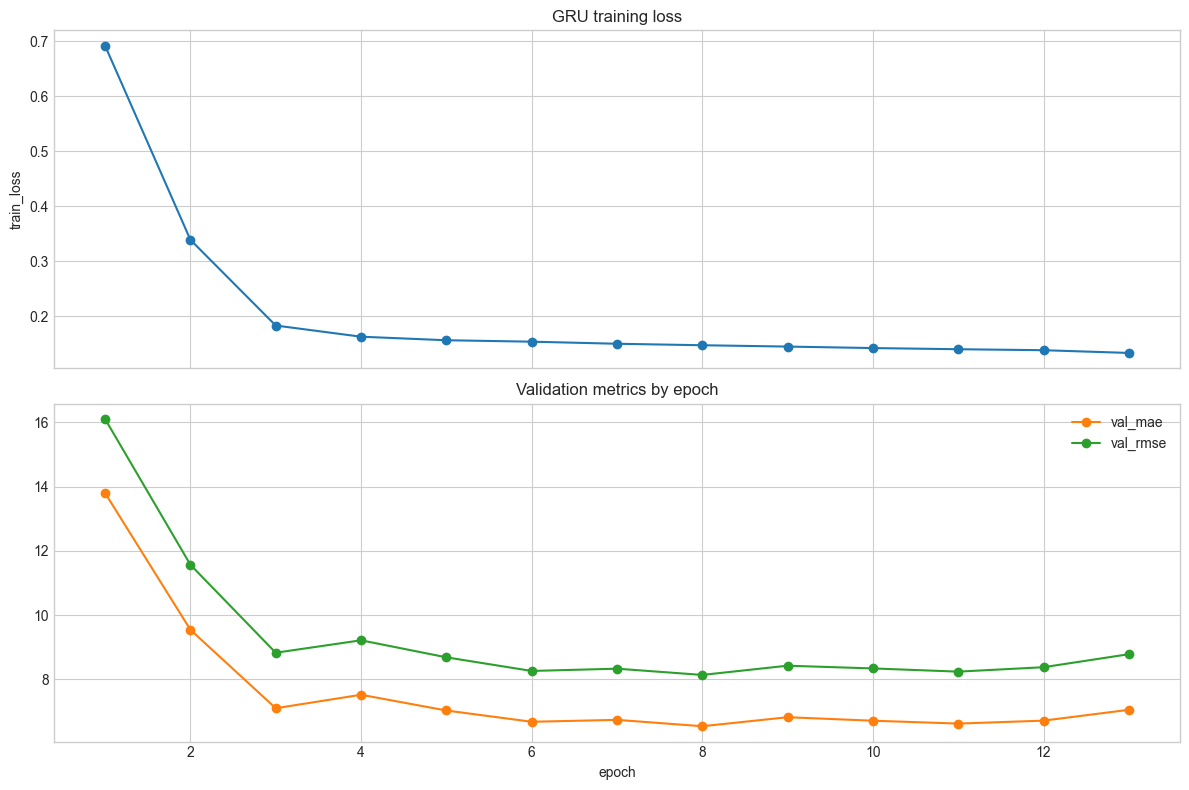

Best epoch: 8
{'mae': 6.545807310033727, 'rmse': 8.141827592638556, 'mape': 4.403041945787334}
Сохранено: /Users/hilez/institute-of-ai/homeworks/HW12/artifacts/best_gru.pt
Сохранено: /Users/hilez/institute-of-ai/homeworks/HW12/artifacts/best_gru_config.json


,split,dataset_len,loader_batches,first_target_timestamp,last_target_timestamp
0,train,2856,45,2025-01-08,2025-05-06 23:00:00
1,validation,648,11,2025-05-07,2025-06-02 23:00:00
2,test,648,11,2025-06-03,2025-06-29 23:00:00


In [8]:
# Dataset / DataLoader for the GRU part: explicit sliding windows inside the notebook.


def build_sequence_indices(
    series_length: int,
    split: TemporalSplit,
    window_size: int,
    horizon: int = 1,
) -> dict[str, list[int]]:
    indices = {"train": [], "val": [], "test": []}
    for target_idx in range(window_size, series_length - horizon + 1):
        if target_idx < split.train_end:
            indices["train"].append(target_idx)
        elif target_idx < split.val_end:
            indices["val"].append(target_idx)
        else:
            indices["test"].append(target_idx)
    return indices


class WindowForecastDataset(Dataset):
    def __init__(
        self,
        scaled_series: np.ndarray,
        sample_indices: Sequence[int],
        window_size: int,
        horizon: int = 1,
    ) -> None:
        self.scaled_series = np.asarray(scaled_series, dtype=np.float32)
        self.sample_indices = list(sample_indices)
        self.window_size = int(window_size)
        self.horizon = int(horizon)

    def __len__(self) -> int:
        return len(self.sample_indices)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        target_idx = self.sample_indices[idx]
        start_idx = target_idx - self.window_size
        end_idx = target_idx
        window = self.scaled_series[start_idx:end_idx]
        target = self.scaled_series[target_idx + self.horizon - 1]
        x = torch.tensor(window[:, None], dtype=torch.float32)
        y = torch.tensor(target, dtype=torch.float32)
        return x, y


target_scaler = StandardScaler()
target_scaler.fit(train[[TARGET_COLUMN]])
scaled_series = target_scaler.transform(frame[[TARGET_COLUMN]]).astype(np.float32).reshape(-1)
sequence_indices = build_sequence_indices(
    series_length=len(frame),
    split=split,
    window_size=config["window_size"],
    horizon=config["horizon"],
)

train_sequence_dataset = WindowForecastDataset(
    scaled_series=scaled_series,
    sample_indices=sequence_indices["train"],
    window_size=config["window_size"],
    horizon=config["horizon"],
)
validation_sequence_dataset = WindowForecastDataset(
    scaled_series=scaled_series,
    sample_indices=sequence_indices["val"],
    window_size=config["window_size"],
    horizon=config["horizon"],
)
test_sequence_dataset = WindowForecastDataset(
    scaled_series=scaled_series,
    sample_indices=sequence_indices["test"],
    window_size=config["window_size"],
    horizon=config["horizon"],
)

train_loader = DataLoader(train_sequence_dataset, batch_size=config["batch_size"], shuffle=True)
validation_loader = DataLoader(validation_sequence_dataset, batch_size=config["batch_size"], shuffle=False)
test_loader = DataLoader(test_sequence_dataset, batch_size=config["batch_size"], shuffle=False)
loaders = {"train": train_loader, "val": validation_loader, "test": test_loader}

sequence_split_overview = pd.DataFrame(
    [
        {
            "split": "train",
            "dataset_len": len(train_sequence_dataset),
            "loader_batches": len(train_loader),
            "first_target_timestamp": frame.iloc[sequence_indices["train"][0]][DATE_COLUMN],
            "last_target_timestamp": frame.iloc[sequence_indices["train"][-1]][DATE_COLUMN],
        },
        {
            "split": "validation",
            "dataset_len": len(validation_sequence_dataset),
            "loader_batches": len(validation_loader),
            "first_target_timestamp": frame.iloc[sequence_indices["val"][0]][DATE_COLUMN],
            "last_target_timestamp": frame.iloc[sequence_indices["val"][-1]][DATE_COLUMN],
        },
        {
            "split": "test",
            "dataset_len": len(test_sequence_dataset),
            "loader_batches": len(test_loader),
            "first_target_timestamp": frame.iloc[sequence_indices["test"][0]][DATE_COLUMN],
            "last_target_timestamp": frame.iloc[sequence_indices["test"][-1]][DATE_COLUMN],
        },
    ]
)

first_window_batch, first_target_batch = next(iter(train_loader))
print(
    {
        "train_window_batch_shape": tuple(first_window_batch.shape),
        "train_target_batch_shape": tuple(first_target_batch.shape),
        "window_size": config["window_size"],
        "batch_size": config["batch_size"],
    }
)

gru_model, gru_history, r1_val_metrics, best_epoch = train_gru_model(
    loaders=loaders,
    frame=frame,
    scaler=target_scaler,
    split_indices=sequence_indices,
    device=DEVICE,
    hidden_size=config["gru_hidden_size"],
    num_layers=config["gru_num_layers"],
    dropout=config["gru_dropout"],
    learning_rate=config["learning_rate"],
    max_epochs=config["max_epochs"],
    patience=config["patience"],
)
gru_model = gru_model.to(DEVICE)
gru_model.eval()
with torch.no_grad():
    preview_batch = next(iter(validation_loader))[0][:1].to(DEVICE)
    preview_prediction = gru_model(preview_batch)
gru_model.train()

gru_history_frame = pd.DataFrame(gru_history)
torch.save(gru_model.state_dict(), ARTIFACTS_DIR / "best_gru.pt")

gru_config = {
    "seed": SEED,
    "device": str(DEVICE),
    "window_size": config["window_size"],
    "horizon": config["horizon"],
    "hidden_size": config["gru_hidden_size"],
    "num_layers": config["gru_num_layers"],
    "dropout": config["gru_dropout"],
    "batch_size": config["batch_size"],
    "learning_rate": config["learning_rate"],
    "max_epochs": config["max_epochs"],
    "epochs_trained": len(gru_history_frame),
    "best_epoch": best_epoch,
    "best_val_metrics": r1_val_metrics,
    "scaler": "StandardScaler(train target only)",
}
save_json(ARTIFACTS_DIR / "best_gru_config.json", gru_config)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(gru_history_frame["epoch"], gru_history_frame["train_loss"], marker="o", color="tab:blue")
axes[0].set_title("GRU training loss")
axes[0].set_ylabel("train_loss")
axes[1].plot(gru_history_frame["epoch"], gru_history_frame["val_mae"], marker="o", color="tab:orange", label="val_mae")
axes[1].plot(gru_history_frame["epoch"], gru_history_frame["val_rmse"], marker="o", color="tab:green", label="val_rmse")
axes[1].set_title("Validation metrics by epoch")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
learning_curves_path = FIGURES_DIR / "gru_learning_curves.png"
fig.savefig(learning_curves_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Best epoch: {best_epoch}")
print(r1_val_metrics)
print(f"Сохранено: {ARTIFACTS_DIR / 'best_gru.pt'}")
print(f"Сохранено: {ARTIFACTS_DIR / 'best_gru_config.json'}")

sequence_split_overview

## 6. Выбор лучшего подхода по validation и одна финальная проверка на test

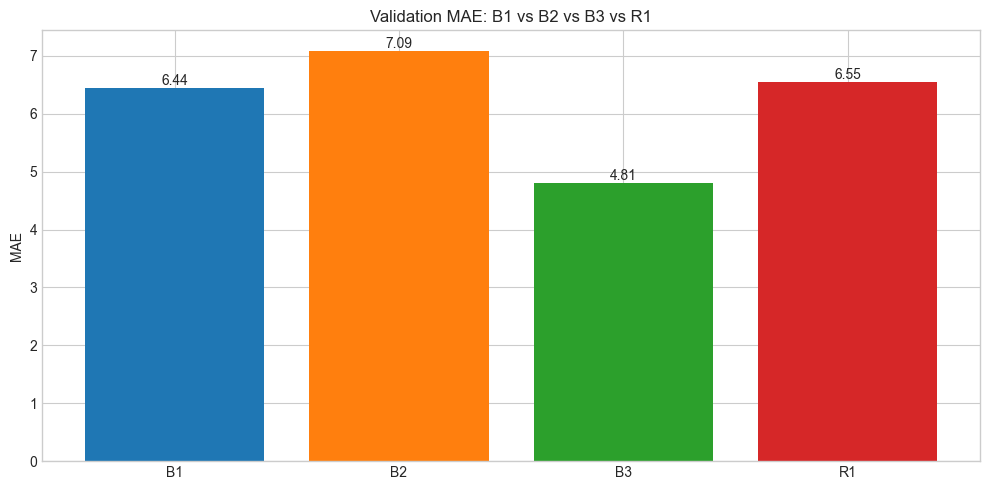

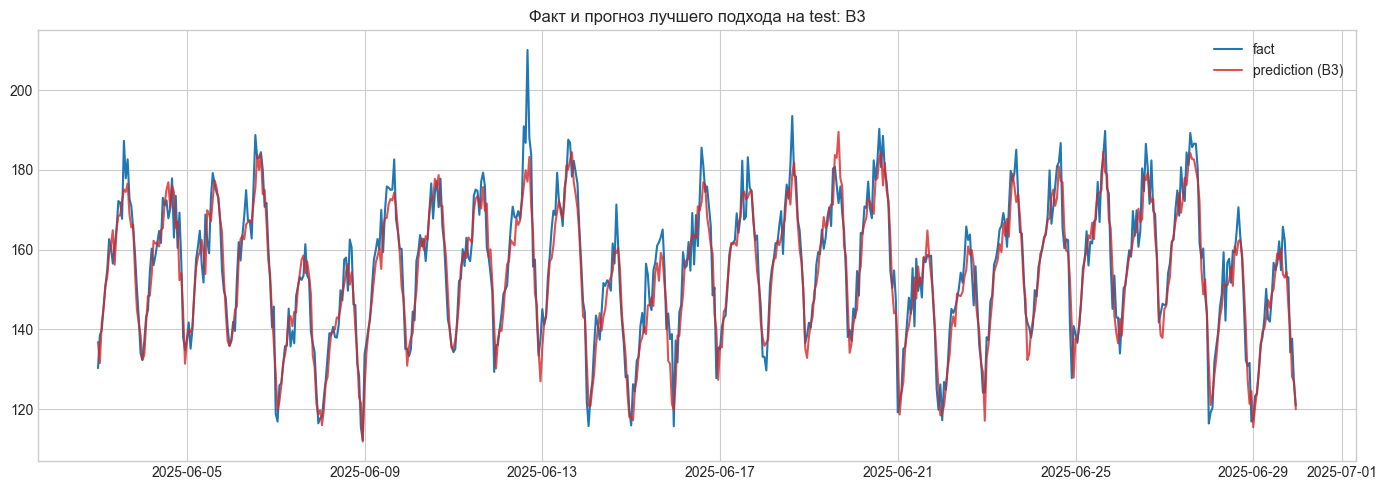

Best validation experiment: B3
{'mae': 4.484559396357419, 'rmse': 5.781570004437087, 'mape': 2.886987596463005}
Сохранено: /Users/hilez/institute-of-ai/homeworks/HW12/artifacts/runs.csv
Сохранено: /Users/hilez/institute-of-ai/homeworks/HW12/artifacts/figures/baselines_compare.png
Сохранено: /Users/hilez/institute-of-ai/homeworks/HW12/artifacts/figures/best_forecast_test.png


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train=3024[2025-01-01 00:00:00..2025-05-06 23:...,NaN,1,naive-last,last observed target,None,None,NaN,0,6.444815,8.201023,4.397922,None,None,None,test withheld until final selection
1,B2,forecasting,S12-hw-dataset.csv,42,train=3024[2025-01-01 00:00:00..2025-05-06 23:...,2.0,1,moving-average(window=2),trailing mean of target,None,None,NaN,0,7.087461,8.827727,4.852069,None,None,None,test withheld until final selection
2,B3,forecasting,S12-hw-dataset.csv,42,train=3024[2025-01-01 00:00:00..2025-05-06 23:...,NaN,1,Ridge(alpha=1.0),"lag_1,lag_7,lag_14,lag_24,lag_168,rolling_mean...",StandardScaler(train only),None,NaN,1,4.807380,6.163091,3.214340,4.484559,5.78157,2.886988,selected best overall; test evaluated once
3,R1,forecasting,S12-hw-dataset.csv,42,train=3024[2025-01-01 00:00:00..2025-05-06 23:...,168.0,1,"GRU(hidden=32, layers=1)",scaled target windows,StandardScaler(train target only),Adam,0.001,13,6.545807,8.141828,4.403042,None,None,None,best_epoch=8; test withheld until final selection


In [9]:
runs_rows = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "split_summary": split.summary,
        "window_size": None,
        "horizon": config["horizon"],
        "model_summary": "naive-last",
        "features_summary": "last observed target",
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": 0,
        "best_val_mae": b1_val_metrics["mae"],
        "best_val_rmse": b1_val_metrics["rmse"],
        "best_val_mape": b1_val_metrics["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "test withheld until final selection",
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "split_summary": split.summary,
        "window_size": config["moving_average_window"],
        "horizon": config["horizon"],
        "model_summary": f"moving-average(window={config['moving_average_window']})",
        "features_summary": "trailing mean of target",
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": 0,
        "best_val_mae": b2_val_metrics["mae"],
        "best_val_rmse": b2_val_metrics["rmse"],
        "best_val_mape": b2_val_metrics["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "test withheld until final selection",
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "split_summary": split.summary,
        "window_size": None,
        "horizon": config["horizon"],
        "model_summary": "Ridge(alpha=1.0)",
        "features_summary": ",".join(BASELINE_FEATURE_COLUMNS),
        "scaler": "StandardScaler(train only)",
        "optimizer": None,
        "lr": None,
        "epochs_trained": 1,
        "best_val_mae": b3_val_metrics["mae"],
        "best_val_rmse": b3_val_metrics["rmse"],
        "best_val_mape": b3_val_metrics["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "test withheld until final selection",
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "split_summary": split.summary,
        "window_size": config["window_size"],
        "horizon": config["horizon"],
        "model_summary": f"GRU(hidden={config['gru_hidden_size']}, layers={config['gru_num_layers']})",
        "features_summary": "scaled target windows",
        "scaler": "StandardScaler(train target only)",
        "optimizer": "Adam",
        "lr": config["learning_rate"],
        "epochs_trained": len(gru_history_frame),
        "best_val_mae": r1_val_metrics["mae"],
        "best_val_rmse": r1_val_metrics["rmse"],
        "best_val_mape": r1_val_metrics["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": f"best_epoch={best_epoch}; test withheld until final selection",
    },
]

column_order = [
    "experiment_id", "task", "dataset", "seed", "split_summary", "window_size", "horizon",
    "model_summary", "features_summary", "scaler", "optimizer", "lr", "epochs_trained",
    "best_val_mae", "best_val_rmse", "best_val_mape", "test_mae", "test_rmse", "test_mape", "notes",
]
runs_frame = rows_to_frame(runs_rows)[column_order]

best_idx = runs_frame["best_val_mae"].idxmin()
best_experiment_id = runs_frame.loc[best_idx, "experiment_id"]

if best_experiment_id == "B1":
    best_test_dates = split.test[DATE_COLUMN]
    best_test_targets = split.test[TARGET_COLUMN].to_numpy()
    best_test_predictions = naive_last_predictions(frame).loc[split.test.index].to_numpy()
    best_test_metrics = regression_metrics(best_test_targets, best_test_predictions)
elif best_experiment_id == "B2":
    best_test_dates = split.test[DATE_COLUMN]
    best_test_targets = split.test[TARGET_COLUMN].to_numpy()
    best_test_predictions = moving_average_predictions(frame, config["moving_average_window"]).loc[split.test.index].to_numpy()
    best_test_metrics = regression_metrics(best_test_targets, best_test_predictions)
elif best_experiment_id == "B3":
    best_test_dates = baseline_test[DATE_COLUMN]
    best_test_targets = baseline_test[TARGET_COLUMN].to_numpy()
    best_test_predictions, best_test_metrics = evaluate_ridge(ridge_model, baseline_test)
else:
    best_test_dates = frame.iloc[sequence_indices["test"]][DATE_COLUMN]
    best_test_targets, best_test_predictions, best_test_metrics = evaluate_gru(
        model=gru_model,
        loader=loaders["test"],
        frame=frame,
        scaler=target_scaler,
        target_indices=sequence_indices["test"],
        device=DEVICE,
    )

runs_frame.loc[best_idx, "test_mae"] = best_test_metrics["mae"]
runs_frame.loc[best_idx, "test_rmse"] = best_test_metrics["rmse"]
runs_frame.loc[best_idx, "test_mape"] = best_test_metrics["mape"]
runs_frame.loc[best_idx, "notes"] = str(runs_frame.loc[best_idx, "notes"]).replace("test withheld until final selection", "selected best overall; test evaluated once")

compare_fig, compare_ax = plt.subplots(figsize=(10, 5))
compare_ax.bar(runs_frame["experiment_id"], runs_frame["best_val_mae"], color=["tab:blue", "tab:orange", "tab:green", "tab:red"])
compare_ax.set_title("Validation MAE: B1 vs B2 vs B3 vs R1")
compare_ax.set_ylabel("MAE")
for x_value, y_value in zip(runs_frame["experiment_id"], runs_frame["best_val_mae"]):
    compare_ax.text(x_value, y_value + 0.05, f"{y_value:.2f}", ha="center")
plt.tight_layout()
compare_path = FIGURES_DIR / "baselines_compare.png"
compare_fig.savefig(compare_path, dpi=150, bbox_inches="tight")
plt.show()

forecast_fig, forecast_ax = plt.subplots(figsize=(14, 5))
forecast_ax.plot(best_test_dates, best_test_targets, label="fact", color="tab:blue")
forecast_ax.plot(best_test_dates, best_test_predictions, label=f"prediction ({best_experiment_id})", color="tab:red", alpha=0.8)
forecast_ax.set_title(f"Факт и прогноз лучшего подхода на test: {best_experiment_id}")
forecast_ax.legend()
plt.tight_layout()
forecast_path = FIGURES_DIR / "best_forecast_test.png"
forecast_fig.savefig(forecast_path, dpi=150, bbox_inches="tight")
plt.show()

runs_path = ARTIFACTS_DIR / "runs.csv"
runs_frame.to_csv(runs_path, index=False)

print(f"Best validation experiment: {best_experiment_id}")
print(best_test_metrics)
print(f"Сохранено: {runs_path}")
print(f"Сохранено: {compare_path}")
print(f"Сохранено: {forecast_path}")

runs_frame

## 7. Краткий вывод по ноутбуку

Лучшая модель — Ridge с лагами и календарными фичами.
GRU не дала прироста и только усложнила решение.
Главное, правильный temporal split и отсутствие утечек

In [10]:
summary_columns = ["experiment_id", "best_val_mae", "best_val_rmse", "best_val_mape", "test_mae", "test_rmse", "test_mape"]
runs_frame[summary_columns].round(4)

,experiment_id,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape
0,B1,6.4448,8.2010,4.3979,None,None,None
1,B2,7.0875,8.8277,4.8521,None,None,None
2,B3,4.8074,6.1631,3.2143,4.484559,5.78157,2.886988
3,R1,6.5458,8.1418,4.4030,None,None,None
